# ATM Breakdown Prediction - Notebook 1: Data Exploration & EDA

This notebook explores the generated ATM telemetry data and performs initial analysis.

## Objectives
1. Load and inspect generated datasets
2. Analyze failure distributions
3. Explore sensor patterns
4. Assess data quality
5. Visualize key patterns

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from datetime import datetime, timedelta
from pathlib import Path
import json
import pandas as pd

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Datasets

In [ ]:
# Go up one level from 'notebooks' to 'ATM', then into 'data/output'
Data_DIR = Path('..') / 'data' / 'output'

# Verify the path exists before loading
print("Path exists:", Data_DIR.exists())

# Load datasets
print("Loading datasets...")
df_sensors = pd.read_csv(Data_DIR / 'sensor_observations.csv', parse_dates=['timestamp'])
df_failures = pd.read_csv(Data_DIR / 'failure_incidents.csv', parse_dates=['start_time', 'end_time'])
df_maintenance = pd.read_csv(Data_DIR / 'maintenance_events.csv', parse_dates=['start_time', 'completion_time'])

# Load metadata
with open(Data_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"\nSensor observations: {df_sensors.shape}")
print(f"Failure incidents: {df_failures.shape}")
print(f"Maintenance events: {df_maintenance.shape}")
print(f"\nMetadata:")
print(json.dumps(metadata['statistics'], indent=2))

Path exists: True
Loading datasets...

Sensor observations: (604800, 54)
Failure incidents: (464, 11)
Maintenance events: (457, 8)

Metadata:
{
  "total_observations": 604800,
  "total_failures": 464,
  "total_maintenance_events": 457,
  "failure_rate_per_atm_year": 80.64761904761906,
  "operational_percentage": 96.08184523809524
}


## 2. Dataset Overview

In [17]:
# Force convert timestamp to datetime
df_sensors['timestamp'] = pd.to_datetime(df_sensors['timestamp'], errors='coerce')

# Basic info
print("=" * 70)
print("SENSOR OBSERVATIONS DATASET")
print("=" * 70)
print(f"\nShape: {df_sensors.shape}")
print(f"Memory usage: {df_sensors.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDate range: {df_sensors['timestamp'].min()} to {df_sensors['timestamp'].max()}")
print(f"Duration: {(df_sensors['timestamp'].max() - df_sensors['timestamp'].min()).days} days")
print(f"\nUnique ATMs: {df_sensors['atm_id'].nunique()}")
print(f"\nOperational status distribution:")
print(df_sensors['operational_status'].value_counts())
print(f"\nOperational percentage: {(df_sensors['operational_status'] == 'operational').mean() * 100:.2f}%")

SENSOR OBSERVATIONS DATASET

Shape: (604800, 54)
Memory usage: 316.36 MB

Date range: 2026-01-01 00:00:00 to 2026-01-12 00:00:00
Duration: 11 days

Unique ATMs: 175

Operational status distribution:
operational_status
operational       581103
out_of_service     23697
Name: count, dtype: int64

Operational percentage: 96.08%


In [18]:
# Column categories
print("\nColumn categories:")
print("-" * 70)

categories = {
    'Identification': ['timestamp', 'atm_id', 'operational_status', 'state', 'degradation_level'],
    'Metadata': ['atm_age_years', 'installation_type'],
    'Network': [col for col in df_sensors.columns if col.startswith('network_')],
    'Power': [col for col in df_sensors.columns if col.startswith('power_')],
    'Temperature': [col for col in df_sensors.columns if col.startswith('temperature_')],
    'Dispenser': [col for col in df_sensors.columns if col.startswith('dispenser_')],
    'Card Reader': [col for col in df_sensors.columns if col.startswith('card_reader_')],
    'Printer': [col for col in df_sensors.columns if col.startswith('printer_')],
    'Software': [col for col in df_sensors.columns if col.startswith('software_')],
    'Monitoring': [col for col in df_sensors.columns if col.startswith('monitoring_')],
}

for category, cols in categories.items():
    print(f"{category}: {len(cols)} columns")

print(f"\nTotal columns: {len(df_sensors.columns)}")


Column categories:
----------------------------------------------------------------------
Identification: 5 columns
Metadata: 2 columns
Network: 6 columns
Power: 7 columns
Temperature: 6 columns
Dispenser: 7 columns
Card Reader: 4 columns
Printer: 5 columns
Software: 6 columns
Monitoring: 6 columns

Total columns: 54


## 3. Failure Analysis

In [19]:
# Failure statistics
print("=" * 70)
print("FAILURE ANALYSIS")
print("=" * 70)

print(f"\nTotal failures: {len(df_failures)}")
print(f"\nFailures by type:")
print(df_failures['failure_type'].value_counts())

print(f"\nFailures by severity:")
print(df_failures['severity'].value_counts())

print(f"\nMaintenance level:")
print(df_failures['maintenance_level'].value_counts())

print(f"\nSudden failures: {df_failures['was_sudden'].sum()} ({df_failures['was_sudden'].mean()*100:.1f}%)")

# Repair duration statistics
print(f"\nRepair duration (hours):")
print(df_failures['repair_duration_hours'].describe())

FAILURE ANALYSIS

Total failures: 464

Failures by type:
failure_type
card_reader    102
printer         84
dispenser       80
network         51
software        43
power           38
thermal         34
hardware        32
Name: count, dtype: int64

Failures by severity:
severity
medium      177
low         146
high         94
critical     47
Name: count, dtype: int64

Maintenance level:
maintenance_level
FLM    310
SLM    154
Name: count, dtype: int64

Sudden failures: 15 (3.2%)

Repair duration (hours):
count    464.000000
mean       3.978819
std        3.076699
min        0.709940
25%        1.810037
50%        2.367643
75%        6.466355
max       14.571343
Name: repair_duration_hours, dtype: float64


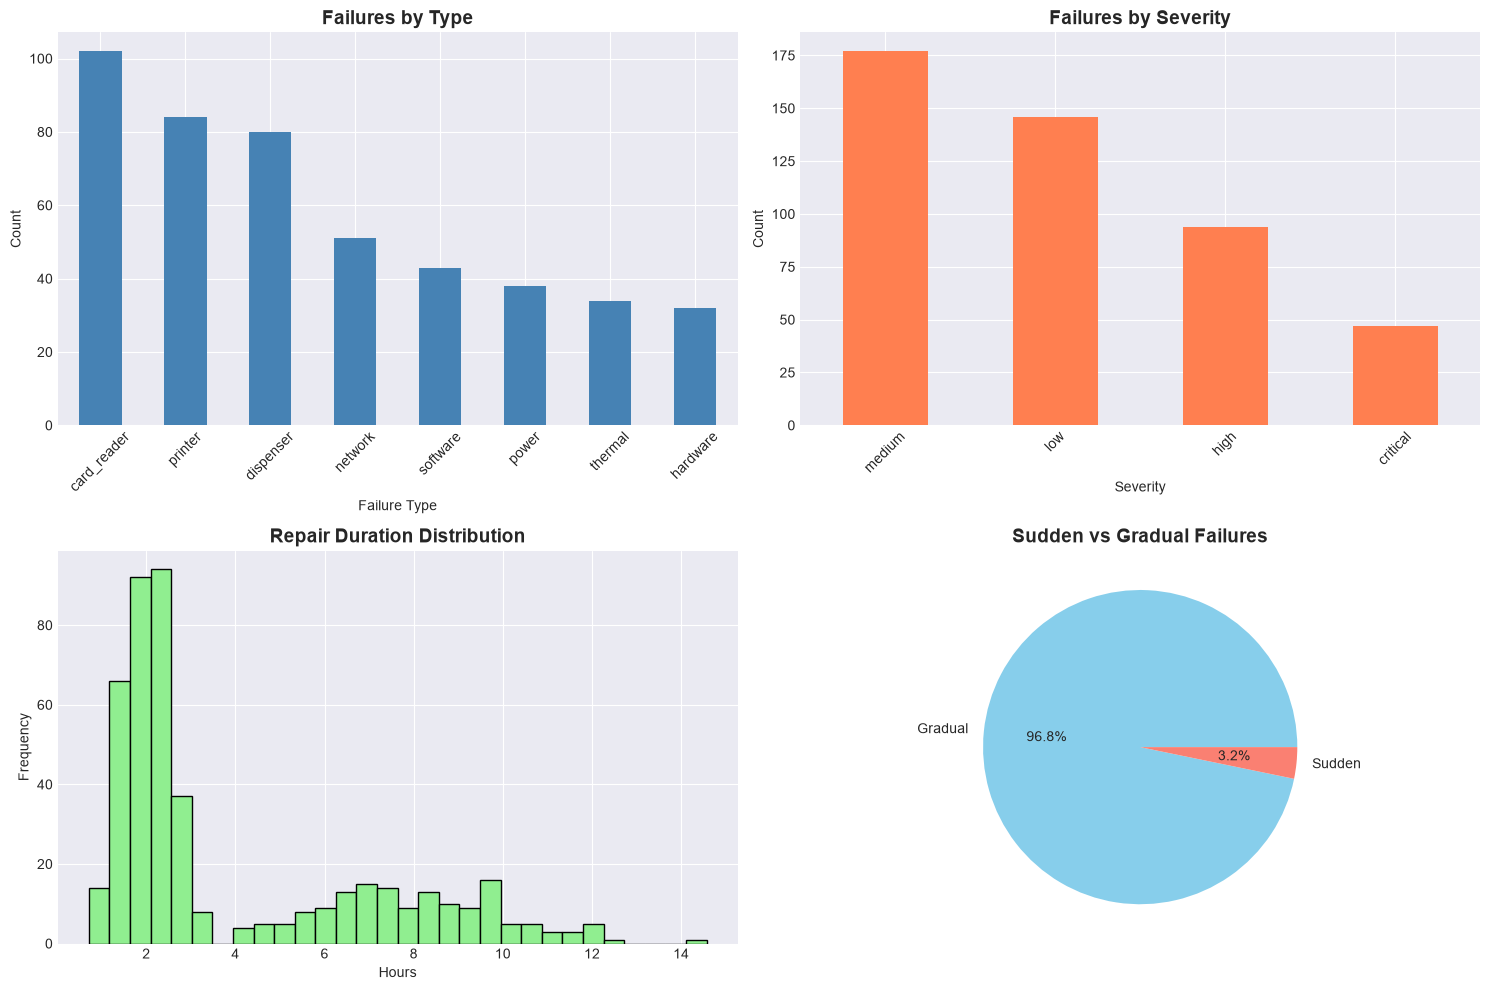

Figure saved: C:\Users\154064\Desktop\ATM\notebooks\figures\01_failure_distribution.png


In [21]:
import os
from pathlib import Path

# Create figures directory if it doesn't exist
fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Visualize failure distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Failure by type
df_failures['failure_type'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Failures by Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Failure Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Failure by severity
df_failures['severity'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Failures by Severity', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Severity')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Repair duration distribution
axes[1, 0].hist(df_failures['repair_duration_hours'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Repair Duration Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hours')
axes[1, 0].set_ylabel('Frequency')

# Sudden vs gradual failures
sudden_counts = df_failures['was_sudden'].value_counts()
axes[1, 1].pie(sudden_counts, labels=['Gradual', 'Sudden'], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
axes[1, 1].set_title('Sudden vs Gradual Failures', fontsize=14, fontweight='bold')

plt.tight_layout()

# Save relative to the current 'notebooks' directory
output_path = fig_dir / '01_failure_distribution.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: {output_path.resolve()}")

## 4. Data Quality Assessment

In [22]:
# Missing data analysis
print("=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

missing_pct = (df_sensors.isnull().sum() / len(df_sensors)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f"\nColumns with missing data: {len(missing_pct)}")
print(f"\nTop 10 columns with missing data:")
print(missing_pct.head(10))

print(f"\nAverage missing rate: {missing_pct.mean():.2f}%")

DATA QUALITY ASSESSMENT

Columns with missing data: 48

Top 10 columns with missing data:
timestamp                                  99.652778
temperature_cabinet_temp_c                  2.020172
temperature_cpu_temp_c                      2.020172
temperature_power_module_temp_c             2.020172
temperature_time_above_warning_temp_min     2.020172
temperature_fan_warning                     2.020172
temperature_fan_speed_rpm                   2.020172
dispenser_failed_pick_count                 2.006944
dispenser_retract_bin_count                 2.006944
dispenser_double_note_count                 2.006944
dtype: float64

Average missing rate: 4.03%


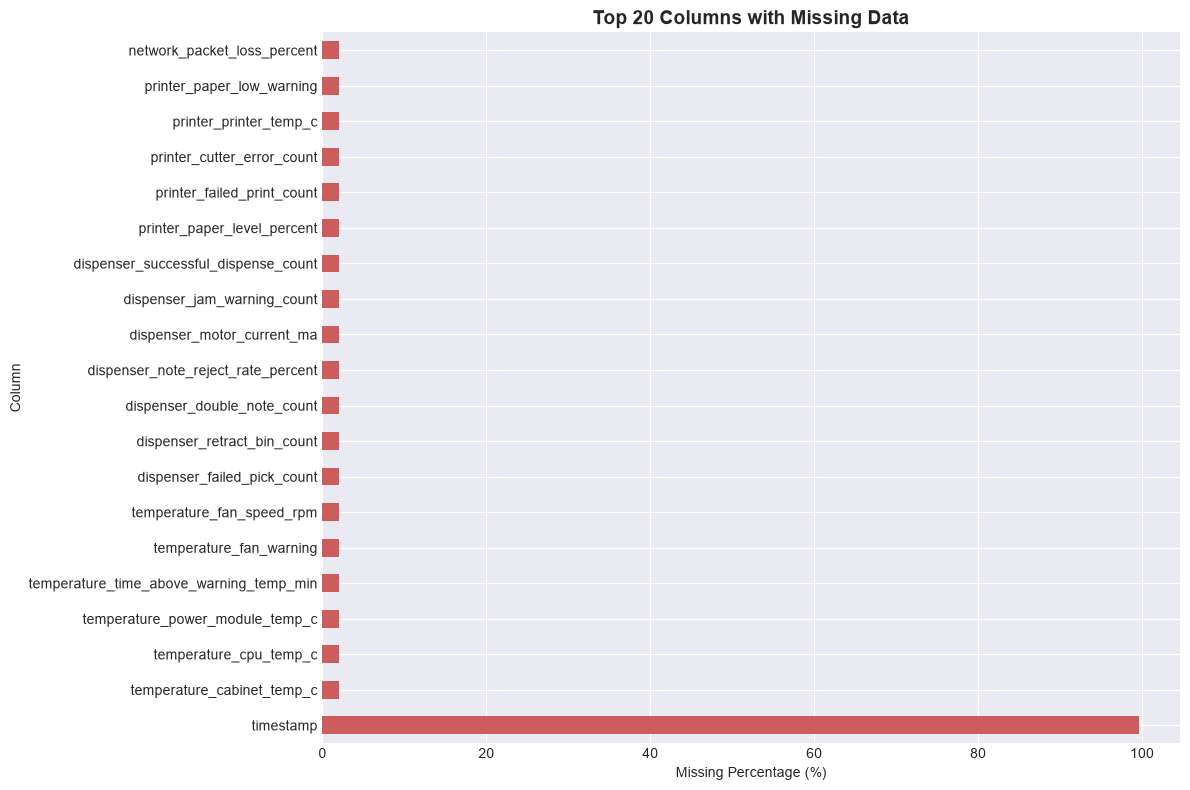

Figure saved: C:\Users\154064\Desktop\ATM\notebooks\figures\01_missing_data.png


In [24]:
from pathlib import Path

# Create figures directory if it doesn't exist
fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 8))

if len(missing_pct) > 0:
    missing_pct.head(20).plot(kind='barh', ax=ax, color='indianred')
    ax.set_title('Top 20 Columns with Missing Data', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_ylabel('Column')
    plt.tight_layout()
    
    output_path = fig_dir / '01_missing_data.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: {output_path.resolve()}")
else:
    print("No missing data found!")

## 5. Sensor Pattern Analysis

In [25]:
# Select key sensors for visualization
key_sensors = [
    'temperature_cabinet_temp_c',
    'power_input_voltage_v',
    'network_signal_strength_dbm',
    'dispenser_motor_current_ma',
    'software_cpu_usage_percent',
    'monitoring_successful_transaction_count'
]

# Summary statistics
print("=" * 70)
print("KEY SENSOR STATISTICS")
print("=" * 70)
print(df_sensors[key_sensors].describe())

KEY SENSOR STATISTICS
       temperature_cabinet_temp_c  power_input_voltage_v  \
count               592582.000000          592751.000000   
mean                    38.163389             219.413238   
std                      8.082469              11.449514   
min                     15.000000               0.000000   
25%                     32.200000             216.300000   
50%                     38.100000             220.000000   
75%                     43.975000             223.600000   
max                     79.700000             260.600000   

       network_signal_strength_dbm  dispenser_motor_current_ma  \
count                592725.000000               592662.000000   
mean                    -65.171477                  804.256186   
std                      10.583899                   69.570874   
min                    -100.000000                  563.000000   
25%                     -72.200000                  766.000000   
50%                     -65.100000       

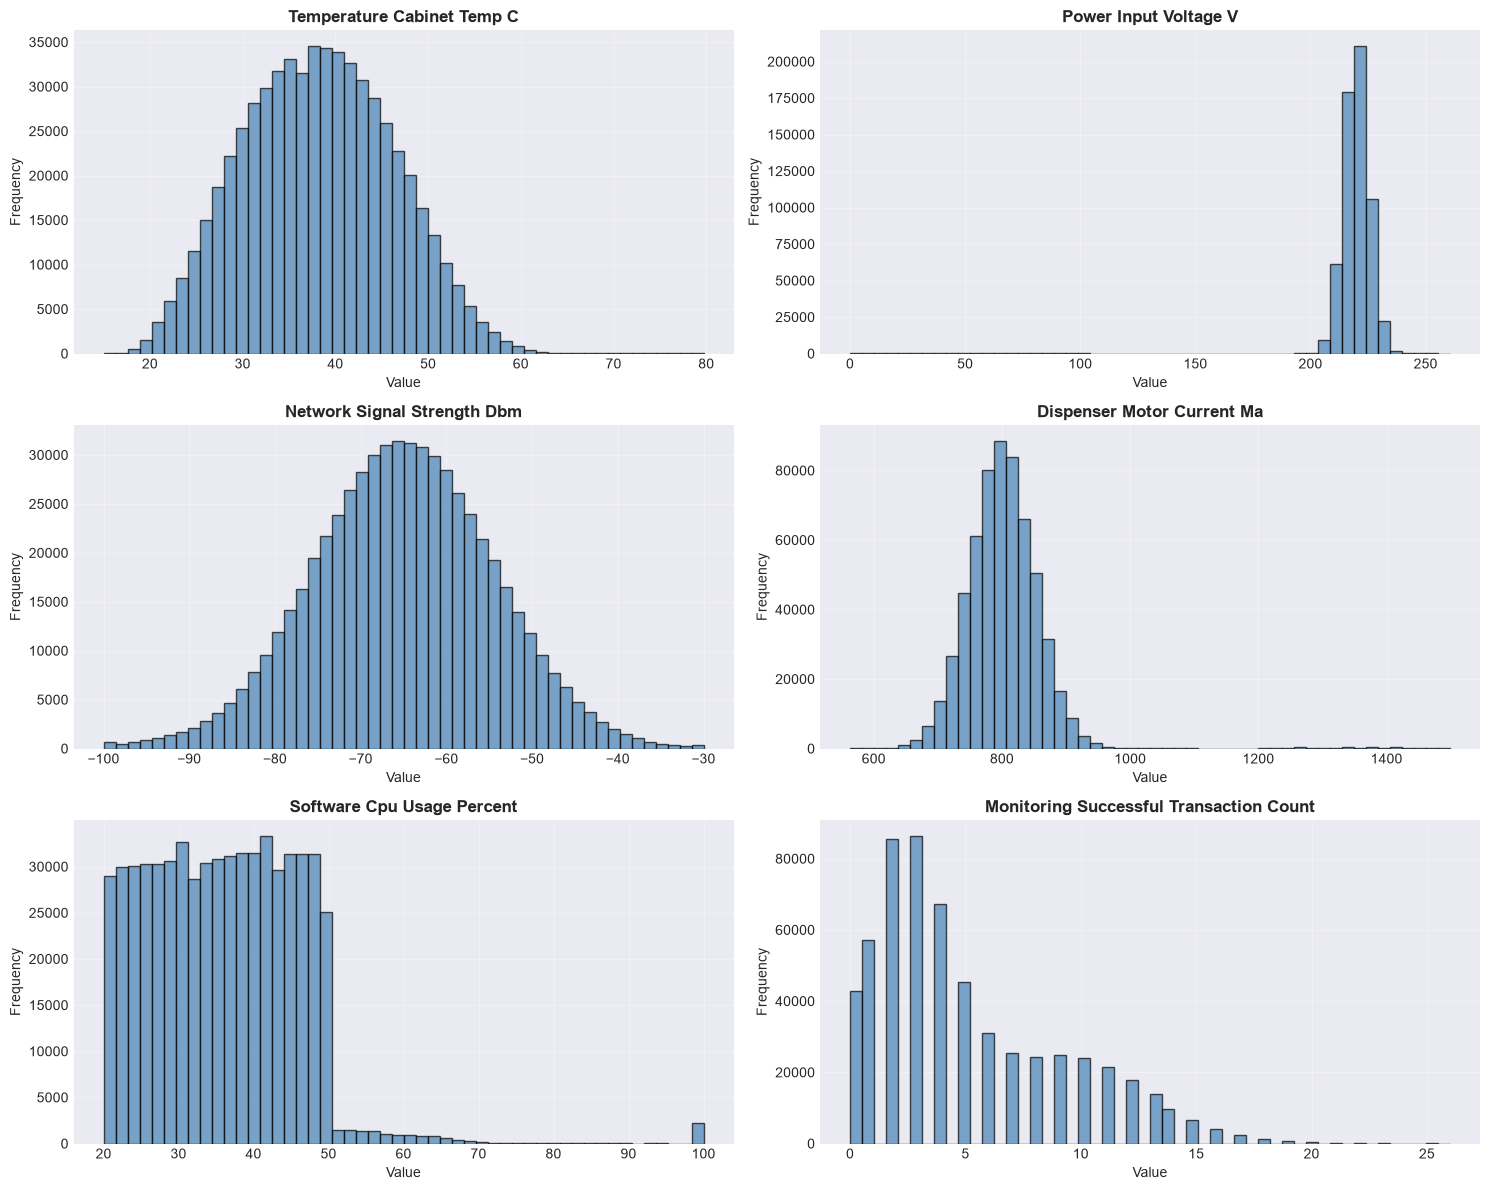

Figure saved: C:\Users\154064\Desktop\ATM\notebooks\figures\01_sensor_distributions.png


In [27]:
from pathlib import Path

# Ensure figures directory exists
fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Visualize sensor distributions
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, sensor in enumerate(key_sensors):
    data = df_sensors[sensor].dropna()
    axes[idx].hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(sensor.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()

output_path = fig_dir / '01_sensor_distributions.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: {output_path.resolve()}")

## 6. Operational vs Failed State Comparison

In [28]:
# Compare sensor values between operational and failed states
operational = df_sensors[df_sensors['operational_status'] == 'operational']
failed = df_sensors[df_sensors['operational_status'] == 'out_of_service']

print("=" * 70)
print("OPERATIONAL VS FAILED STATE COMPARISON")
print("=" * 70)
print(f"\nOperational observations: {len(operational):,}")
print(f"Failed observations: {len(failed):,}")
print(f"\nFailure rate: {len(failed) / len(df_sensors) * 100:.2f}%")

OPERATIONAL VS FAILED STATE COMPARISON

Operational observations: 581,103
Failed observations: 23,697

Failure rate: 3.92%


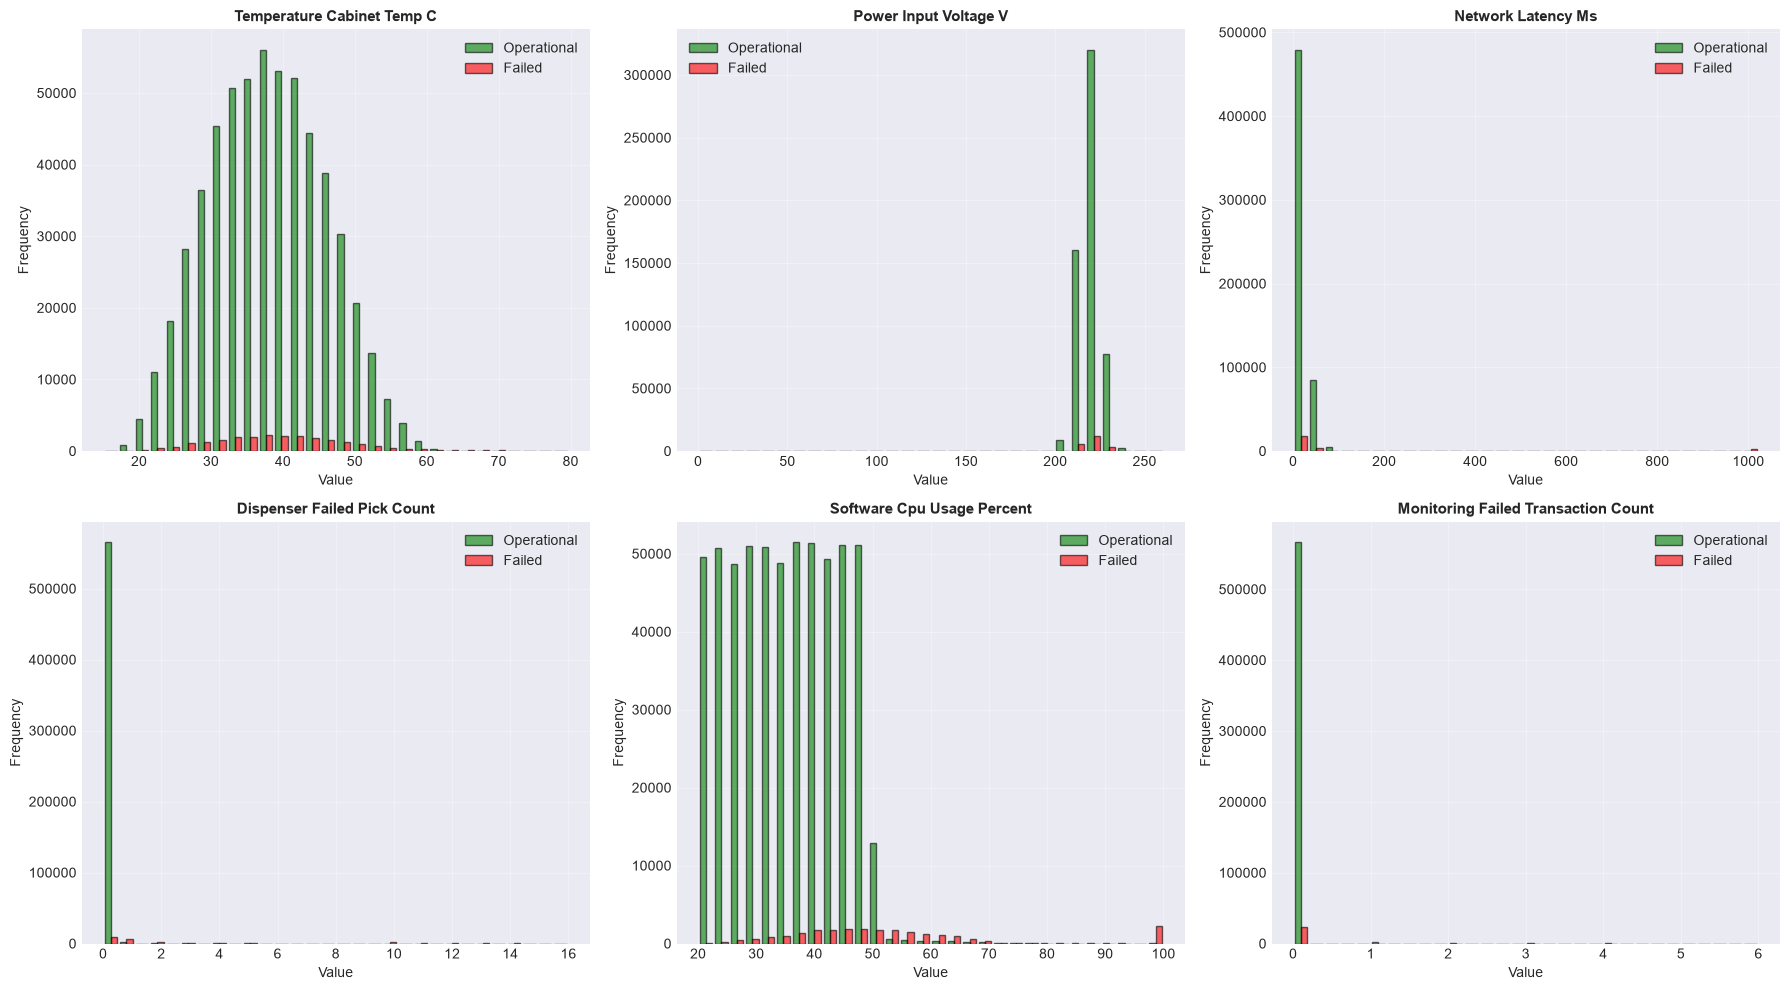

Figure saved: C:\Users\154064\Desktop\ATM\notebooks\figures\01_operational_vs_failed.png


In [30]:
from pathlib import Path

# Ensure figures directory exists
fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Visualize operational vs failed comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

comparison_sensors = [
    'temperature_cabinet_temp_c',
    'power_input_voltage_v',
    'network_latency_ms',
    'dispenser_failed_pick_count',
    'software_cpu_usage_percent',
    'monitoring_failed_transaction_count'
]

for idx, sensor in enumerate(comparison_sensors):
    op_data = operational[sensor].dropna()
    fail_data = failed[sensor].dropna()
    
    axes[idx].hist([op_data, fail_data], bins=30, label=['Operational', 'Failed'], 
                    color=['green', 'red'], alpha=0.6, edgecolor='black')
    axes[idx].set_title(sensor.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()

output_path = fig_dir / '01_operational_vs_failed.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: {output_path.resolve()}")

## 7. Temporal Patterns

In [31]:
# Analyze temporal patterns
df_sensors['hour'] = df_sensors['timestamp'].dt.hour
df_sensors['day_of_week'] = df_sensors['timestamp'].dt.dayofweek

# Failures over time
df_failures['date'] = df_failures['start_time'].dt.date
failures_per_day = df_failures.groupby('date').size()

print("=" * 70)
print("TEMPORAL PATTERNS")
print("=" * 70)
print(f"\nFailures per day:")
print(failures_per_day.describe())

TEMPORAL PATTERNS

Failures per day:
count    12.000000
mean     38.666667
std       7.523700
min      24.000000
25%      36.000000
50%      38.500000
75%      40.000000
max      56.000000
dtype: float64


In [ ]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Failures over time
failures_per_day.plot(ax=axes[0], marker='o', color='darkred', linewidth=2)
axes[0].set_title('Failures Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Failures')
axes[0].grid(True, alpha=0.3)

# Transaction patterns by hour
hourly_transactions = df_sensors.groupby('hour')['monitoring_successful_transaction_count'].mean()
hourly_transactions.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average Transactions by Hour of Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Transactions')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('notebooks/figures/01_temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: notebooks/figures/01_temporal_patterns.png")

## 8. Summary & Key Findings

In [32]:
print("=" * 70)
print("SUMMARY & KEY FINDINGS")
print("=" * 70)

print(f"""
Dataset Overview:
- Total observations: {len(df_sensors):,}
- Number of ATMs: {df_sensors['atm_id'].nunique()}
- Time period: {(df_sensors['timestamp'].max() - df_sensors['timestamp'].min()).days} days
- Features: {len(df_sensors.columns)} columns

Failure Statistics:
- Total failures: {len(df_failures)}
- Failure rate: {len(failed) / len(df_sensors) * 100:.2f}%
- Most common failure: {df_failures['failure_type'].value_counts().index[0]}
- Sudden failures: {df_failures['was_sudden'].sum()} ({df_failures['was_sudden'].mean()*100:.1f}%)

Data Quality:
- Average missing rate: {missing_pct.mean():.2f}%
- Operational percentage: {(df_sensors['operational_status'] == 'operational').mean() * 100:.2f}%

Next Steps:
1. Feature engineering with rolling windows
2. Create target variable: fails_within_next_30m
3. Remove location identifiers (atm_id, state, degradation_level)
4. Split data (chronological + unseen ATM holdout)
5. Train predictive models
""")

print("\n" + "=" * 70)
print("Notebook 1 Complete! Proceed to Notebook 2: Feature Engineering")
print("=" * 70)

SUMMARY & KEY FINDINGS

Dataset Overview:
- Total observations: 604,800
- Number of ATMs: 175
- Time period: 11 days
- Features: 56 columns

Failure Statistics:
- Total failures: 464
- Failure rate: 3.92%
- Most common failure: card_reader
- Sudden failures: 15 (3.2%)

Data Quality:
- Average missing rate: 4.03%
- Operational percentage: 96.08%

Next Steps:
1. Feature engineering with rolling windows
2. Create target variable: fails_within_next_30m
3. Remove location identifiers (atm_id, state, degradation_level)
4. Split data (chronological + unseen ATM holdout)
5. Train predictive models


Notebook 1 Complete! Proceed to Notebook 2: Feature Engineering
